# Downloading Dataset

In [3]:
!gdown 1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7

Downloading...
From (original): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7
From (redirected): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7&confirm=t&uuid=4304a84b-9688-46cb-b3e4-284ed419c237
To: /content/finetune_sharegpt.jsonl
100% 194M/194M [00:01<00:00, 105MB/s] 


In [4]:
!gdown 109g0JvBajIj_YgBDs5AufiD29nJViE1u

Downloading...
From (original): https://drive.google.com/uc?id=109g0JvBajIj_YgBDs5AufiD29nJViE1u
From (redirected): https://drive.google.com/uc?id=109g0JvBajIj_YgBDs5AufiD29nJViE1u&confirm=t&uuid=19caacaf-88bf-4a75-bd01-af282dafd54e
To: /content/dataset.zip
100% 808M/808M [00:13<00:00, 62.0MB/s]


In [5]:
!unzip -q dataset.zip -d dataset/

In [6]:
import os
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

In [7]:
image_folder_path = Path('/content/dataset')
image_classes = os.listdir(image_folder_path)
image_classes

['Rice Turgro', 'Rice Blast', 'Browon Spot', 'Leaf Scaled', 'Sheath Blight']

In [8]:
leaf_images = defaultdict(list)

for image_class in tqdm((image_classes)):
  for image in os.listdir(image_folder_path / image_class):
    leaf_images[image_class].append(Image.open(image_folder_path / image_class / image))

100%|██████████| 5/5 [00:00<00:00, 14.81it/s]


In [9]:
def get_random_image(given_image_class):
  image_class = None
  for folder_name in image_classes:
    if re.sub(r'[^A-Za-z]+', '', folder_name) == re.sub(r'[^A-Za-z]+', '', given_image_class):
      image_class = folder_name

  if image_class is None:
    return None
  return random.choice(leaf_images[image_class])

In [10]:
import time
import json
import re
import random

with open('finetune_sharegpt.jsonl') as f:
  data = [json.loads(sample) for sample in f.readlines()]

# Examples

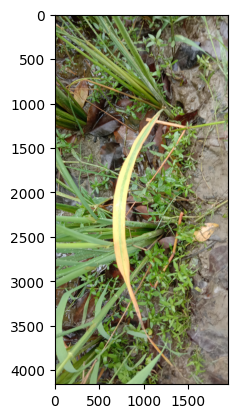

In [11]:
import matplotlib.pyplot as plt
plt.imshow(leaf_images['Rice Turgro'][0])

In [12]:
data[0]

{'id': 'rice_blast_001',
 'crop': 'rice',
 'symptom_text': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।',
 'image_path': None,
 'disease_label': 'Rice Blast (ধানের ব্লাস্ট)',
 'qa_flow': [{'role': 'assistant',
   'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
  {'role': 'user',
   'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
  {'role': 'assistant',
   'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
  {'role': 'user',
   'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'}],
 'advice': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সব

In [13]:
SYSTEM_PROMPT = ''' You are an experienced agricultural expert. You will be provided with an image showing a plant or crop disease.
                    Your task is to interact with the user in a conversational manner to diagnose the problem. Ask relevant follow-up questions to clarify symptoms, crop type, growing conditions, and location if needed.
                    Based on the image and the user’s responses, identify the possible disease or issue, explain its causes, and provide clear, practical guidance on prevention and treatment.
                    All responses must be in Bengali, using simple, farmer-friendly language that is easy to understand and apply.
                '''

In [14]:
def fix_single_conversation(sample):
  merged = []
  last_role = None
  for s in sample:
    current_role = s['role']
    current_content = s['content'][0]['text']
    if last_role and last_role == current_role:
        merged[-1]['content'][0]['text'] += f'\n{current_content}'
    else:
        merged.append({'role': current_role, 'content': current_content})
        last_role = current_role
  return merged


In [15]:
def single_conv(sample):
    image = get_random_image(sample['disease_label'])

    if image is None:
        return None
    all_messages = []
    all_messages.append({
        'role': 'user',
        'content': [
            {'type': 'text', 'text': SYSTEM_PROMPT + '\n' + sample.get('symptom_text', '')},
            {'type': 'image', 'image': image}
        ]
    })

    for qa_entry in sample['qa_flow']:
        all_messages.append({
            'role': qa_entry['role'],
            'content': [{'type': 'text', 'text': qa_entry['content']}]
        })

    all_messages.append({
        'role': 'assistant',
        'content': [{'type': 'text', 'text': sample['advice'] + '\n\nNote: ' + sample['notes']}]
    })

    merged_messages = []

    for msg in all_messages:
        if not merged_messages:
            merged_messages.append(msg)
        elif merged_messages[-1]['role'] == msg['role']:
            last_msg = merged_messages[-1]

            last_text_item_found = False
            for item in reversed(last_msg['content']):
                if item['type'] == 'text':
                    item['text'] += '\n\n' + msg['content'][0]['text']
                    last_text_item_found = True
                    break

            if not last_text_item_found:
                last_msg['content'].append({'type': 'text', 'text': msg['content'][0]['text']})
        else:
            merged_messages.append(msg)

    return merged_messages


dataset = []
failed_samples = []

for idx, sample in enumerate(tqdm(data)):
    try:
        conv = single_conv(sample)
        if conv is not None:
            roles = [msg['role'] for msg in conv]
            has_consecutive = False
            for i in range(len(roles) - 1):
                if roles[i] == roles[i + 1]:
                    has_consecutive = True
                    print(f"Sample {idx} has consecutive {roles[i]} roles. Roles: {roles}")
                    break

            if not has_consecutive:
                dataset.append(conv)
            else:
                failed_samples.append(idx)
        else:
            failed_samples.append(idx)
    except Exception as e:
        print(f"Error processing sample {idx}: {e}")
        failed_samples.append(idx)

print(f"\nSuccessfully processed: {len(dataset)} samples")
print(f"Failed samples: {len(failed_samples)}")


if dataset:
    print("\nSample conversation structure:")
    sample_conv = dataset[0]
    for i, msg in enumerate(sample_conv):
        content_types = [item['type'] for item in msg['content']]
        print(f"{i}. Role: {msg['role']}, Content types: {content_types}")

100%|██████████| 96311/96311 [00:06<00:00, 13951.93it/s]


Successfully processed: 48205 samples
Failed samples: 48106

Sample conversation structure:
0. Role: user, Content types: ['text', 'image']
1. Role: assistant, Content types: ['text']
2. Role: user, Content types: ['text']
3. Role: assistant, Content types: ['text']
4. Role: user, Content types: ['text']
5. Role: assistant, Content types: ['text']


In [16]:
len(dataset)

48205

In [17]:
dataset[5]

[{'role': 'user',
  'content': [{'type': 'text',
    'text': ' You are an experienced agricultural expert. You will be provided with an image showing a plant or crop disease.\n                    Your task is to interact with the user in a conversational manner to diagnose the problem. Ask relevant follow-up questions to clarify symptoms, crop type, growing conditions, and location if needed.\n                    Based on the image and the user’s responses, identify the possible disease or issue, explain its causes, and provide clear, practical guidance on prevention and treatment.\n                    All responses must be in Bengali, using simple, farmer-friendly language that is easy to understand and apply.\n                \nধানের পাতায় হালকা বাদামী রঙের রেখা দেখা যাচ্ছে, এবং পাতাগুলো দুর্বল হয়ে যাচ্ছে। এটা কি রোগ?'},
   {'type': 'image',
    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1952x4160>}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'te

# Data Structure

# Split

In [18]:
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# Qwen3-VL-4B

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

In [24]:
# !pip install -U bitsandbytes -q

In [2]:
from unsloth import FastVisionModel
import torch


model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.4: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

In [19]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# Fine Tuning

In [20]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [21]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 48,205 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.274700
2,1.247900
3,1.229200
4,1.203700
5,1.031400
6,0.927500
7,0.785000
8,0.711600
9,0.671100
10,0.739100


# Loss Curve

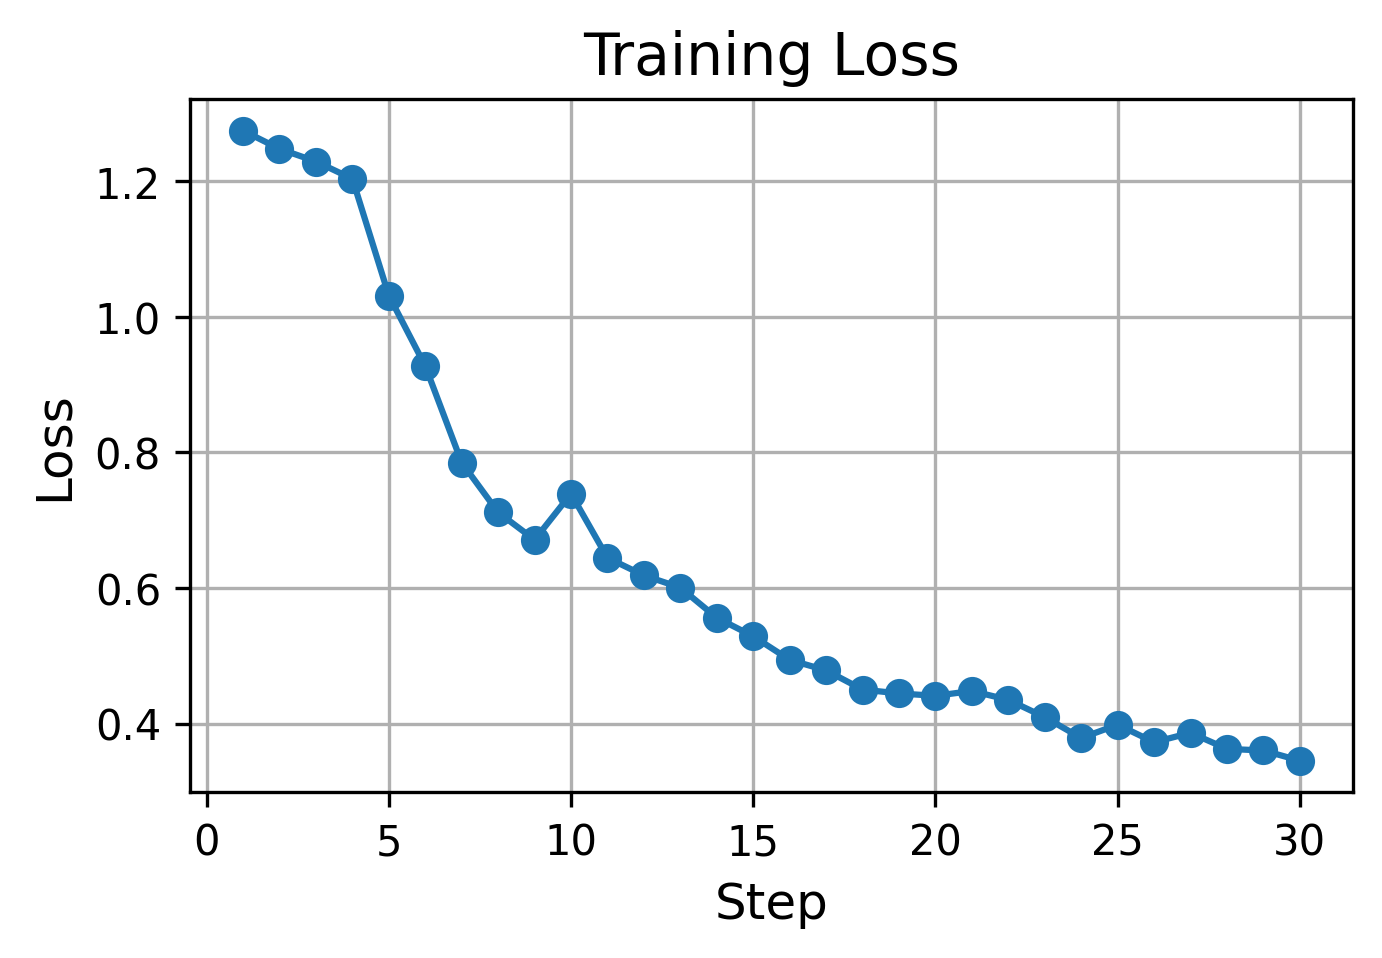

In [22]:
import json
import matplotlib.pyplot as plt

file_path = "/content/outputs/checkpoint-30/trainer_state.json"

with open(file_path, 'r') as f:
    trainer_state = json.load(f)

log_history = trainer_state.get("log_history", [])

steps = [entry["step"] for entry in log_history]
losses = [entry["loss"] for entry in log_history]

plt.figure(figsize=(5, 3), dpi=300)
plt.plot(steps, losses, marker='o')
plt.title('Training Loss', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.grid(True)
plt.show()

# Save Model

In [ ]:
!rm -rf llama.cpp
!git clone --recursive https://github.com/ggerganov/llama.cpp
!cd llama.cpp && mkdir build && cd build && cmake .. && cmake --build .
!cp llama.cpp/convert_hf_to_gguf.py llama.cpp/unsloth_convert_hf_to_gguf.py


In [ ]:
# model.save_pretrained_gguf("lora_model", tokenizer, quantization_method = "q4_k_m")
model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit")

# Evaluation

In [23]:
import torch

def generate_conv(conv):
    input_text = tokenizer.apply_chat_template(conv, add_generation_prompt=True)
    inputs = tokenizer(
        text=input_text,
        images=None, # Explicitly indicate no image input
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        use_cache=True,
        temperature=1.1,
        repetition_penalty=2.0,
        min_p=0.1
    )

    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens=False)[0].split('<end_of_turn>')
    # generated_text = [text for text in generated_text if 'model' in text][-2:]
    # generated_text = ''.join(text.replace('<start_of_turn>model\n', '') for text in generated_text)
    return generated_text

In [29]:
from tqdm import tqdm

predictions = []
actuals = []
indices = len(test_dataset)

for j in tqdm(range(indices)):
    prompt = test_dataset[j][:-1]
    actual_response = test_dataset[j][-1]
    generated_response = generate_conv(prompt)
    predictions.append(generated_response)
    actuals.append(actual_response)

100%|██████████| 100/100 [43:24<00:00, 26.04s/it]


In [25]:
import nltk
nltk.download('wordnet')

!pip install rouge_score jiwer -q
class BengaliTokenizer:
    def tokenize(self, text):
        # For traditional metrics and TF-IDF, a simple whitespace split is often used
        return text.split()

[nltk_data] Downloading package wordnet to /root/nltk_data...


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.9 MB/s eta 0:00:00


In [26]:
!pip install -q sentence-transformers bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00


In [30]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from collections import Counter
import math
import nltk
nltk.download('wordnet')
from rouge_score import rouge_scorer
from jiwer import wer

from bert_score import score
from sentence_transformers import SentenceTransformer, util

# Initialize lists for storing metric results
bleu_scores = []
meteor_scores = []
rouge1_fmeasures = []
rouge2_fmeasures = []
rougel_fmeasures = []
wer_scores = []
bert_p = []
bert_r = []
bert_f1 = []
cosine_similarities = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True, tokenizer=BengaliTokenizer())
model_cs = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

cleaned_predictions = []
cleaned_actuals = []

for pred_raw, actual_raw in zip(predictions, actuals):
    cleaned_pred_text = ""
    if isinstance(pred_raw, list) and len(pred_raw) > 0:
        full_generated_text = pred_raw[0]
        assistant_turn_marker = "<start_of_turn>model\n"
        if assistant_turn_marker in full_generated_text:
            segments_after_assistant_tag = full_generated_text.split(assistant_turn_marker)
            last_assistant_response_segment = segments_after_assistant_tag[-1]
            cleaned_pred_text = last_assistant_response_segment.split('</s>')[0].strip()
        else:
            cleaned_pred_text = full_generated_text.strip()

    # Extract actual text: actual_raw is like {'role': 'assistant', 'content': [{'type': 'text', 'text': '...'}]}
    cleaned_actual_text = ""
    if isinstance(actual_raw, dict) and 'content' in actual_raw and \
       len(actual_raw['content']) > 0 and 'text' in actual_raw['content'][0]:
        cleaned_actual_text = actual_raw['content'][0]['text']

    cleaned_predictions.append(cleaned_pred_text)
    cleaned_actuals.append(cleaned_actual_text)

# Calculate metrics using the cleaned texts
for pred_text, ref_text in zip(cleaned_predictions, cleaned_actuals):
    # Ensure both are strings for tokenization and string-based metrics
    pred_text = str(pred_text)
    ref_text = str(ref_text)

    # Tokenize for n-gram based metrics
    pred_tokens = BengaliTokenizer().tokenize(pred_text)
    ref_tokens = BengaliTokenizer().tokenize(ref_text)

    # BLEU Score
    if ref_tokens: # Ensure reference is not empty
        bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
        bleu_scores.append(bleu)
    else:
        bleu_scores.append(0.0) # Append 0 if no reference to compare against

    # METEOR Score
    if ref_tokens:
        meteor = meteor_score([ref_tokens], pred_tokens)
        meteor_scores.append(meteor)
    else:
        meteor_scores.append(0.0)

    # ROUGE Scores
    scores = scorer.score(ref_text, pred_text)
    rouge1_fmeasures.append(scores['rouge1'].fmeasure)
    rouge2_fmeasures.append(scores['rouge2'].fmeasure)
    rougel_fmeasures.append(scores['rougeL'].fmeasure)

    # WER Score
    wer_value = wer(ref_text, pred_text)
    wer_scores.append(wer_value)

    # BertScore (calculates P, R, F1 for each pair)
    # Check if texts are non-empty before running BertScore
    if pred_text and ref_text:
        P, R, F1 = score([pred_text], [ref_text], lang='bn', verbose=False)
        bert_p.append(P.item())
        bert_r.append(R.item())
        bert_f1.append(F1.item())
    else:
        bert_p.append(0.0)
        bert_r.append(0.0)
        bert_f1.append(0.0)

    # Cosine Similarity
    if pred_text and ref_text:
        embeddings1 = model_cs.encode(pred_text, convert_to_tensor=True)
        embeddings2 = model_cs.encode(ref_text, convert_to_tensor=True)
        cosine_score = util.cos_sim(embeddings1, embeddings2).item()
        cosine_similarities.append(cosine_score)
    else:
        cosine_similarities.append(0.0)


# Print average scores
print("BLEU:", np.mean(bleu_scores))
print("METEOR:", np.mean(meteor_scores))
print("ROUGE-1 F-measure:", np.mean(rouge1_fmeasures))
print("ROUGE-2 F-measure:", np.mean(rouge2_fmeasures))
print("ROUGE-L F-measure:", np.mean(rougel_fmeasures))
print("WER:", np.mean(wer_scores))
print("BertScore Precision:", np.mean(bert_p))
print("BertScore Recall:", np.mean(bert_r))
print("BertScore F1:", np.mean(bert_f1))
print("Cosine Similarity:", np.mean(cosine_similarities))

def calculate_ngram_perplexity(corpus_texts, n=2):
    if not isinstance(corpus_texts, list) or not all(isinstance(item, str) for item in corpus_texts):
        corpus_texts = [str(item) for item in corpus_texts]
    filtered_corpus = [text for text in corpus_texts if text.strip()]
    if not filtered_corpus:
        return float('inf')

    all_tokens = " ".join(filtered_corpus).split()

    if len(all_tokens) < n:
        return float('inf')

    ngrams = [tuple(all_tokens[i:i+n]) for i in range(len(all_tokens)-n+1)]
    ngram_counts = Counter(ngrams)
    context_counts = Counter([ng[:-1] for ng in ngrams])

    log_prob_sum = 0.0
    N = len(ngrams)

    if N == 0: return float('inf')

    for ng in ngrams:
        context = ng[:-1]
        if context_counts[context] == 0:
            prob = 1e-10
        else:
            prob = ngram_counts[ng] / context_counts[context]

        log_prob_sum += math.log(prob)
    return math.exp(-log_prob_sum / N)
print("Perplexity:", calculate_ngram_perplexity(cleaned_predictions, n=2))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


BLEU: 0.002516676013488569
METEOR: 0.05596632405359491
ROUGE-1 F-measure: 0.03536477824792649
ROUGE-2 F-measure: 0.005660341375807748
ROUGE-L F-measure: 0.024767499051188215
WER: 7.275082614313281
BertScore Precision: 0.5306195685267449
BertScore Recall: 0.6448636084794999
BertScore F1: 0.5820059937238693
Cosine Similarity: 0.19602995709516108
Perplexity: 2.9298837642589217
